In [1]:
import os
os.environ['KERAS_BACKEND'] = 'torch'
from time import localtime, strftime

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import keras
from keras.callbacks import LearningRateScheduler, ModelCheckpoint, Callback

from keras.datasets import cifar10
from keras.utils import plot_model

from utils import *
from models import *


In [2]:
CLASSES = ('airplane', 'automobile', 'bird', 'cat', 'deer',
         'dog', 'frog', 'horse', 'ship', 'truck')
INPUT_SHAPE = (32, 32, 3)

BACK_C = (.12, .12, .12, 1.)
plt.style.use('dark_background')

make_directories()


In [3]:
params = {'figure.facecolor': BACK_C,
          'axes.facecolor': BACK_C,
          'axes.titleweight': 'bold'}

plt.rcParams.update(params)


In [4]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# One Cycle Policy

Sur base de:
- [Learning rate cycliques](https://arxiv.org/abs/1506.01186)
- [One Cycle policy](https://arxiv.org/abs/1803.09820)

>Plutôt que d'avoir un *learning rate* fixe, il est plus intéressant de le faire varier. Cela a souvent pour conséquence d'accélérer la convergence.
>
>Une première approche est de proposer un cycle que l'on repète $n$ fois durant l'entraînement. Un cycle correspond à une augmentation d'un *learning rate* de départ jusqu'à un maximum puis un retour à sa valeur de départ (*cfr.* [premier lien](https://arxiv.org/abs/1506.01186)).

>Une seconde approche consiste à ne proposer qu'un seul cycle suivi d'une seconde phase où le *learning rate* diminue progressivement jusqu'à
un minimum fixé (*cfr.* [second lien](https://arxiv.org/abs/1803.09820)). Cette méthode peut être apparentée à une méthode de régularisation.
>
>Dans cette seconde approche le *learning rate* est modifié de manière linéaire(facultatif) et progressive à chaque step/itération/batch.
>
>Pour la première phase, nous fixons un *learning rate* de départ, un maximum et un nombre total d'itérations.
>La variation du *learning rate* à chaque itération est calculée comme suit:
> - (lr max - lr départ)/(itérations/2)
>
>Ensuite, il suffit de faire monter progressivement le *learning rate* jusqu'au maximum puis de redescendre au minimum.
>
>La sconde phase consiste à faire diminuer le *learning rate* jusqu'à son minimum sur un certain nombre d'itérations.
>
>Le plus difficile consiste à identifier les *learning rate* max, min et de départ. Nous y reviendrons.
>
>Notre implémention ne prend en charge que la variation du *learning rate* mais dans les articles précédemment cités, il est également préconisé de modifier le momentum, si applicable (*e.g.* SGD, rmsprop).
>
>D'ailleurs, il serait peut-être plus intéressant de se tourner vers rmsprop ou SGD comme optimizer dans le cas de cifar10.

<br>

In [5]:
class OneCycleScheduler(Callback):
    """
    Implementation of the One Cycle Policy base on the Leslie N. Smith's papers:
    - https://arxiv.org/abs/1506.01186
    - https://arxiv.org/abs/1803.09820

    #TODO: momentum decay for SGD or RMSprop.
    """

    def __init__(self,  lr_start: float, lr_min: float, lr_max: float, cycle_steps: int, p2_iter: int) -> None:
        """
        Compute the decays for the first and second phase.
        Args:
            lr_start (float): starting learning rate.
            lr_min (float): minimum learning rate.
            lr_max (float): maximum learning rate.
            cycle_steps (int): number of steps for the first phase.
            p2_iter (int): number of steps for the second phase.
        """
        super().__init__()
        self.lr_start = lr_start
        self.lr_min = lr_min
        self.lr_max = lr_max
        self.cycle_steps = cycle_steps
        self.phase2_iter = p2_iter

        self.decay = (lr_max-lr_start)/(cycle_steps/2)
        self.decay_p2 = (lr_start-lr_min)/p2_iter

    def on_train_begin(self, logs: dict) -> None:
        """
        Initialize step count to 0. Used to track the steps during the training.
        We could also track the steps with self.model.history.params.

        We also initialize a list to store all the lr and add it to the history when training is finished.

        In the end we set the starting learning rate for the optimizer.

        Args:
            logs (dict): metrics logs.
        """
        self.step = 0
        self.lrs = []

        self.model.optimizer.learning_rate.assign(self.lr_start)

    def on_train_batch_end(self, batch: int, logs: dict) -> None:
        """
        Increment the step and set new learning rate.

        Args:
            batch (int): a batch.
            logs (dict): metrics logs.
        """
        # track steps or self.model.history.params
        self.step += 1
        self.set_lr(logs)

    def on_train_end(self, logs: dict) -> None:
        """
        Update history with the learning rate historic.

        Args:
            logs (dict): metrics logs.
        """
        self.model.history.history['lr_steps'] = self.lrs

    def set_lr(self, logs: dict) -> None:
        """
        Increase the learning progressively from the starting learning rate to the maximum and then it goes back to its starting point.

        In the second phase the learning rate progressively decays to the minimum.

        Args:
            logs (dict): logs metrics that we update with the learning for each step.
        """
        lr = float(self.model.optimizer.learning_rate)

        #TODO: conditional structure slows the training
        # phase 1 ascending
        if self.step <= self.cycle_steps/2:
            lr += self.decay

        # phase 2
        elif self.step > self.cycle_steps:
            lr -= self.decay_p2

        # phase 1 descending
        else:
            lr -= self.decay

        self.lrs.append(lr)
        logs.update({'lr': lr})
        self.model.optimizer.learning_rate.assign(lr)


In [6]:
# model = get_simple_model(10, optimizer='adam', padding='same')
# model.build((None, 32, 32, 3))
# print(model.summary())
# plot_model(model, expand_nested=True, show_shapes=True)

In [19]:
now = strftime('%y%m%d_%H%M%S', localtime())
log_dir = f'logs/fit/{now}'
model_dir = f'models/{now}.keras'

p1_iter = 4000
p2_iter = 1600
epochs = int((p1_iter+p2_iter)/40)

callbacks = [OneCycleScheduler(0.0008, 0.0001, 0.08, p1_iter, p2_iter),
             ModelCheckpoint(model_dir, monitor='val_accuracy', save_best_only=True)]


#TODO as suggested by Deepmind team in VGG for scale image recognition
# grater depth less filters leads to implicti regularisation
# ADD a conv layer, less filters
cnn = get_simple_model(10,
                       optimizer=keras.optimizers.Adam(),
                       padding='same')

cnn.fit(X_train, y_train, validation_split=.2,
        epochs=epochs, batch_size=1024, callbacks=callbacks)


Epoch 1/140
40/40 [==============================] - 4s 82ms/step - loss: 1.7206 - accuracy: 0.4030 - lr: 0.0016 - val_loss: 2.7673 - val_accuracy: 0.0997
Epoch 2/140
40/40 [==============================] - 2s 41ms/step - loss: 1.3203 - accuracy: 0.5280 - lr: 0.0032 - val_loss: 3.8913 - val_accuracy: 0.0997
Epoch 3/140
40/40 [==============================] - 3s 82ms/step - loss: 1.2045 - accuracy: 0.5685 - lr: 0.0048 - val_loss: 2.8478 - val_accuracy: 0.2258
Epoch 4/140
40/40 [==============================] - 2s 41ms/step - loss: 1.0817 - accuracy: 0.6141 - lr: 0.0064 - val_loss: 5.1168 - val_accuracy: 0.1323
Epoch 5/140
40/40 [==============================] - 2s 39ms/step - loss: 1.0120 - accuracy: 0.6389 - lr: 0.0079 - val_loss: 5.2936 - val_accuracy: 0.1097
Epoch 6/140
40/40 [==============================] - 3s 80ms/step - loss: 0.9777 - accuracy: 0.6524 - lr: 0.0095 - val_loss: 2.3975 - val_accuracy: 0.3700
Epoch 7/140
40/40 [==============================] - 3s 80ms/step - lo

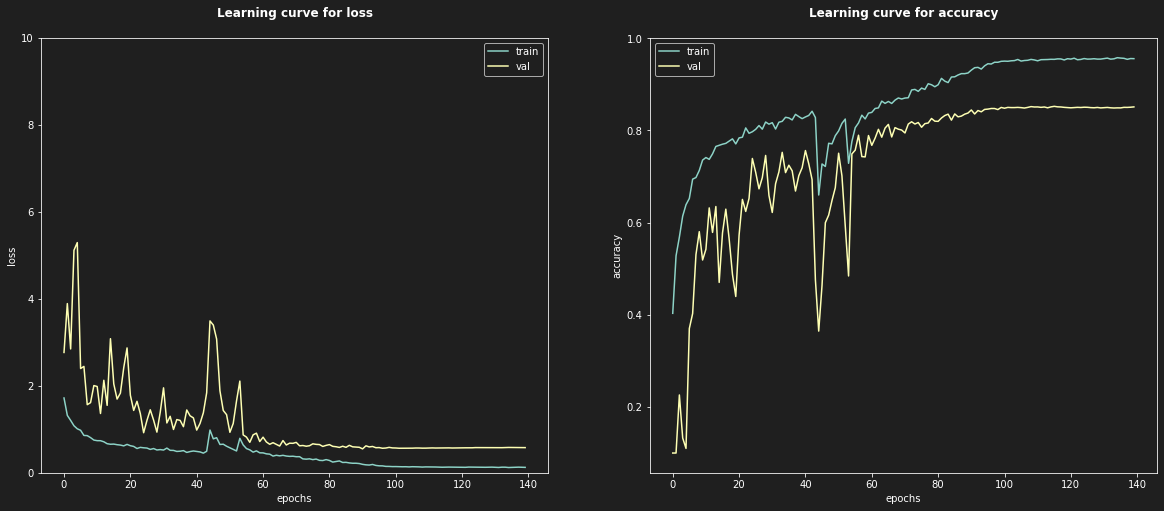

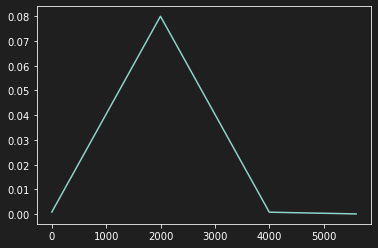

In [20]:
plot_lc(cnn.history.history)

plt.plot(cnn.history.history['lr_steps'])
plt.show()

In [21]:
y_pred = np.argmax(cnn.predict(X_test), axis=1)

get_reports(y_test, y_pred, CLASSES, 'testset', log_dir)

# Resnet

>Pour les détails de l'implémentation:
>
>[https://arxiv.org/abs/1512.03385](https://arxiv.org/abs/1512.03385)

<br>

In [9]:
# model = get_resnet34(10, INPUT_SHAPE, 'adam')
# print(model.summary())
# plot_model(model, expand_nested=True, show_shapes=True)

In [7]:
resnet = get_resnet34(10, INPUT_SHAPE, 'adam')

now = strftime('%y%m%d_%H%M%S', localtime())
log_dir = f'logs/fit/{now}'
model_dir = f'models/{now}.keras'

p1_iter = 4000
p2_iter = 1600
epochs = int((p1_iter+p2_iter)/40)

callbacks = [OneCycleScheduler(0.0008, 0.0001, 0.08, p1_iter, p2_iter),
             ModelCheckpoint(model_dir, monitor='val_accuracy', save_best_only=True)]

resnet.fit(X_train, y_train, epochs=epochs, batch_size=1024, validation_split=.2, callbacks=callbacks)


Epoch 1/40
40/40 [==============================] - 7s 81ms/step - loss: 2.1248 - accuracy: 0.2646 - lr: 0.0059 - val_loss: 532975.1250 - val_accuracy: 0.1014
Epoch 2/40
40/40 [==============================] - 2s 61ms/step - loss: 1.7053 - accuracy: 0.3701 - lr: 0.0158 - val_loss: 9979.2725 - val_accuracy: 0.1014
Epoch 3/40
40/40 [==============================] - 2s 61ms/step - loss: 1.6112 - accuracy: 0.4040 - lr: 0.0257 - val_loss: 2.3038 - val_accuracy: 0.1016
Epoch 4/40
40/40 [==============================] - 2s 61ms/step - loss: 1.6523 - accuracy: 0.3846 - lr: 0.0356 - val_loss: 331.5454 - val_accuracy: 0.1003
Epoch 5/40
40/40 [==============================] - 2s 62ms/step - loss: 1.6504 - accuracy: 0.4069 - lr: 0.0456 - val_loss: 401.9405 - val_accuracy: 0.1014
Epoch 6/40
40/40 [==============================] - 2s 61ms/step - loss: 1.5063 - accuracy: 0.4505 - lr: 0.0555 - val_loss: 888.7653 - val_accuracy: 0.1082
Epoch 7/40
40/40 [==============================] - 2s 61ms/st

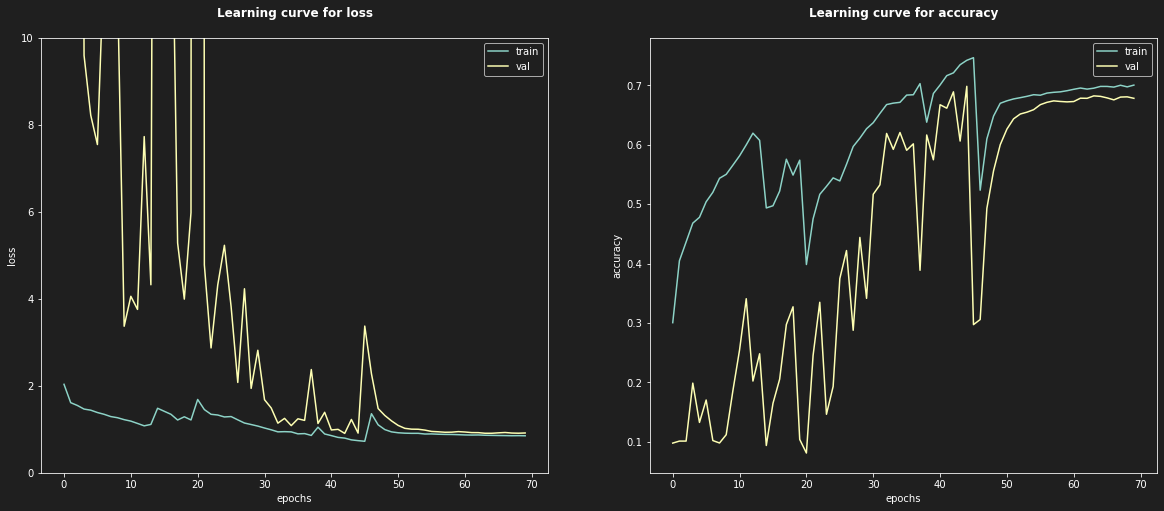

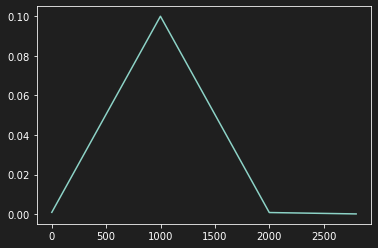

In [8]:
plot_lc(resnet.history.history)

plt.plot(resnet.history.history['lr_steps'])
plt.show()

In [ ]:
y_pred = np.argmax(cnn.predict(X_test), axis=1)

get_reports(y_test, y_pred, CLASSES, 'testset', log_dir)